# Resta

La **resta de imágenes** es una operación de procesamiento digital que consiste en restar los valores de los píxeles de una imagen con respecto a otra.

Matemáticamente:

I_{resultado}(x,y)=I_1(x,y)-I_2(x,y)

Donde:

* (I_1(x,y)) = píxel de la primera imagen
* (I_2(x,y)) = píxel de la segunda imagen
* (I_{resultado}(x,y)) = píxel obtenido después de la resta

---

# ¿Cómo funciona?

Cada píxel tiene un valor de intensidad o color.
La resta se realiza píxel por píxel:

Ejemplo en escala de grises:

* Imagen A → píxel = 200
* Imagen B → píxel = 120

Resultado:

200-120=80

El nuevo píxel tendrá intensidad 80.

---

# ¿Qué ocurre en imágenes RGB/BGR?

La resta se hace canal por canal:

[
(B_1-G_1-R_1) - (B_2-G_2-R_2)
]

Ejemplo:

* Imagen 1 → `(200,150,100)`
* Imagen 2 → `(50,20,10)`

Resultado:

```python
(150,130,90)
```

---

# ¿Para qué sirve la resta de imágenes?

Se usa mucho en visión artificial para:

* detectar movimiento,
* eliminar fondo,
* resaltar diferencias,
* comparar imágenes,
* detectar cambios entre cuadros de video.

---

# Ejemplo típico: detección de movimiento

Si una cámara toma dos imágenes consecutivas:

* las zonas iguales se cancelan,
* las zonas que cambiaron quedan resaltadas.

Así se detecta movimiento fácilmente.

---

# Implementación en OpenCV

OpenCV realiza la resta con:

```python
resultado = cv2.subtract(imagen1, imagen2)
```

o también:

```python
resultado = imagen1 - imagen2
```

Pero `cv2.subtract()` es más segura porque evita errores con valores negativos.

---

# Importante: saturación de valores

Los píxeles normalmente están entre:

[
0 \leq pixel \leq 255
]

Si una resta produce un valor negativo:

50-100=-50

OpenCV lo ajusta automáticamente a:

0

Esto se llama **saturación** o **clipping**.

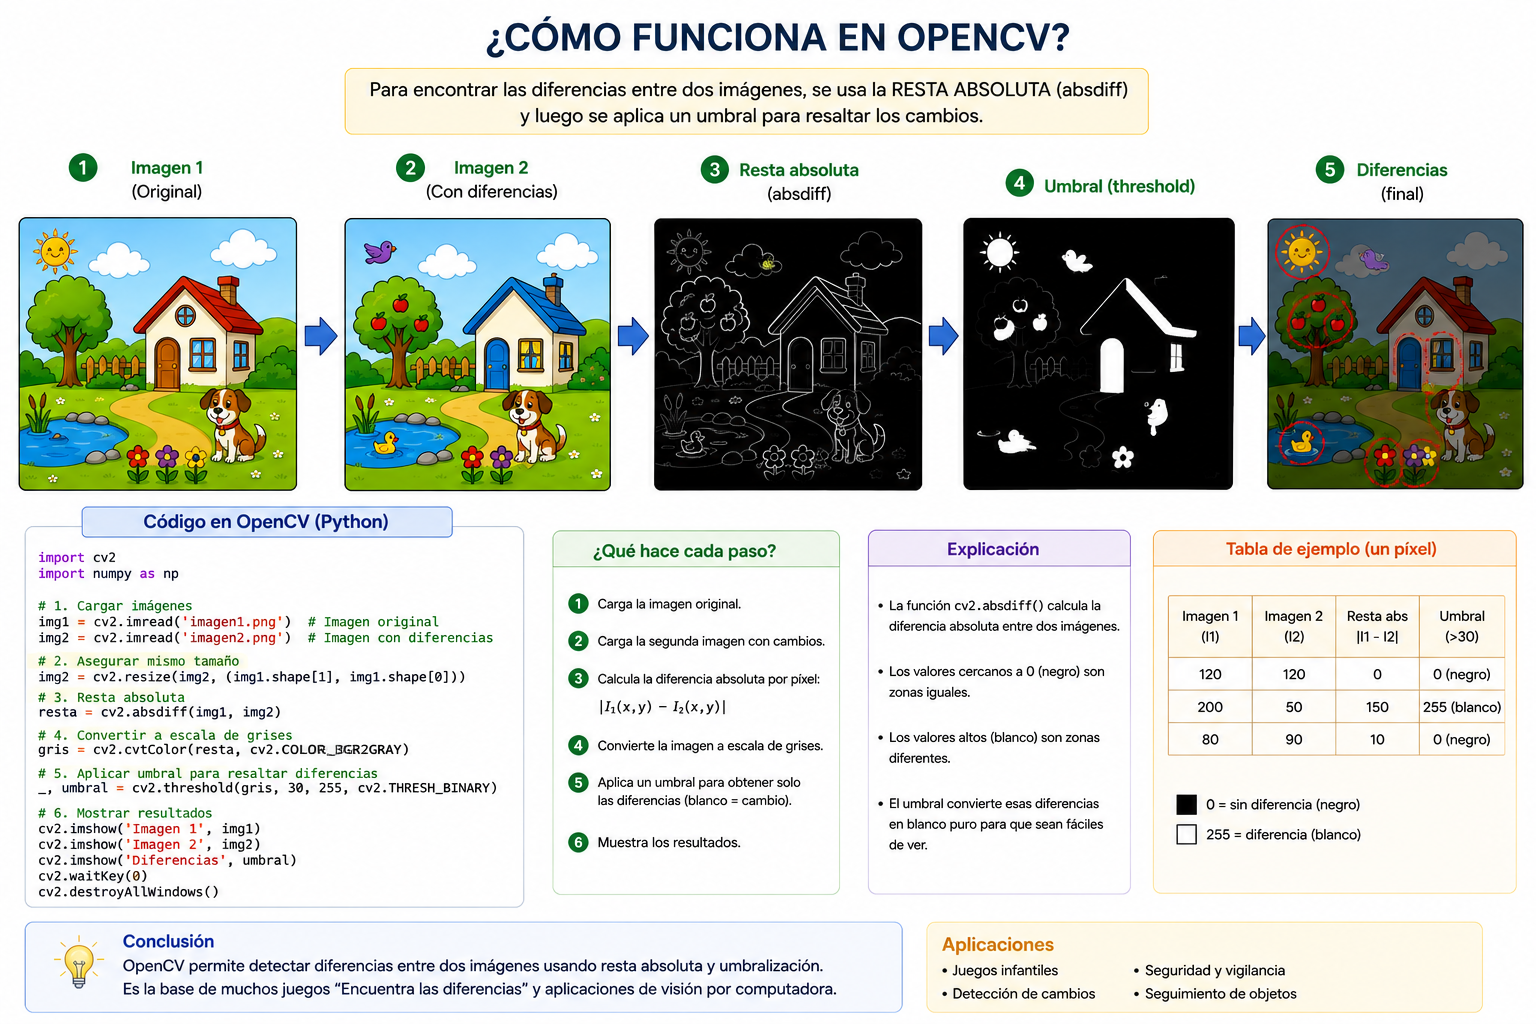


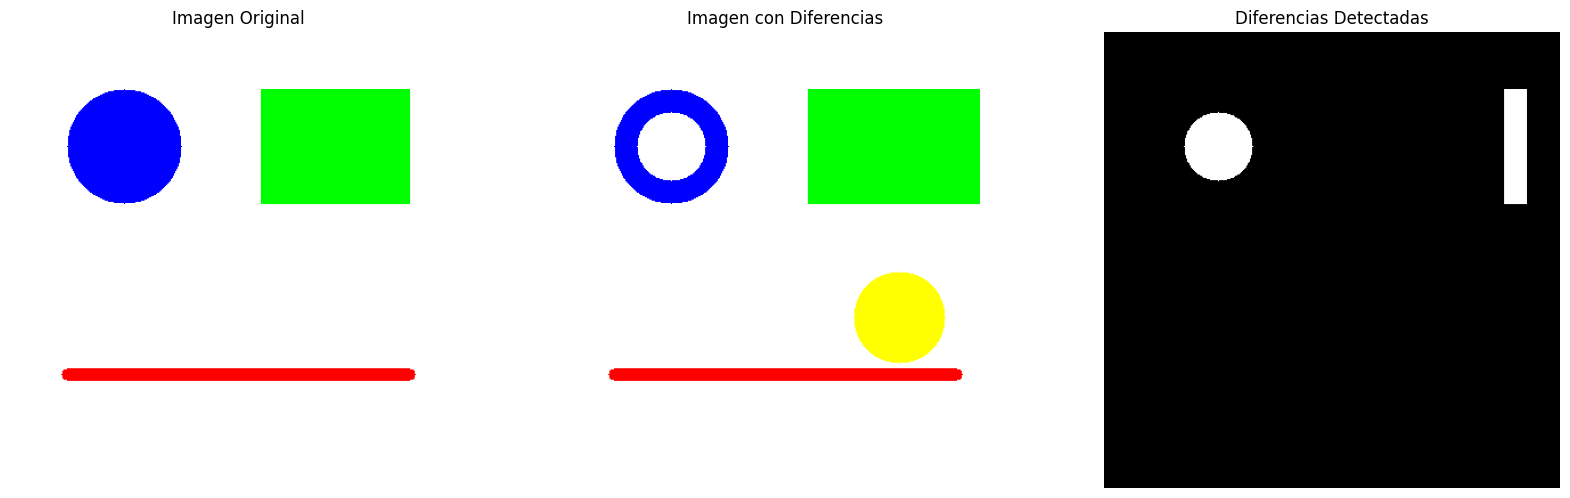

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CREAR IMAGEN ORIGINAL
# =========================

img1 = np.ones((400,400,3), dtype=np.uint8) * 255

# Dibujos originales
cv2.circle(img1, (100,100), 50, (255,0,0), -1)
cv2.rectangle(img1, (220,50), (350,150), (0,255,0), -1)
cv2.line(img1, (50,300), (350,300), (0,0,255), 10)

# =========================
# CREAR SEGUNDA IMAGEN
# =========================

img2 = img1.copy()

# DIFERENCIA 1: círculo más pequeño
cv2.circle(img2, (100,100), 30, (255,255,255), -1)

# DIFERENCIA 2: agregar otro círculo
cv2.circle(img2, (300,250), 40, (0,255,255), -1)

# DIFERENCIA 3: mover rectángulo
cv2.rectangle(img2, (240,50), (370,150), (0,255,0), -1)

# =========================
# DETECTAR DIFERENCIAS
# =========================

diff = cv2.absdiff(img1, img2)

# Escala de grises
gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

# Resaltar diferencias
_, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

# =========================
# CONVERTIR A RGB
# =========================

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# =========================
# MOSTRAR RESULTADOS
# =========================

plt.figure(figsize=(20,6))

# Imagen original
plt.subplot(1,3,1)
plt.imshow(img1_rgb)
plt.title("Imagen Original")
plt.axis("off")

# Imagen con diferencias
plt.subplot(1,3,2)
plt.imshow(img2_rgb)
plt.title("Imagen con Diferencias")
plt.axis("off")

# Diferencias detectadas
plt.subplot(1,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Diferencias Detectadas")
plt.axis("off")

plt.show()

# Operación Lógica AND

La operación lógica **AND** en procesamiento de imágenes es una técnica que compara dos imágenes píxel por píxel utilizando la operación lógica binaria AND.

Se usa principalmente para:

* aplicar máscaras,
* extraer regiones,
* segmentar objetos,
* conservar partes específicas de una imagen.

---

# Teoría del operador AND

La operación AND funciona con lógica binaria:

| A | B | A AND B |
| - | - | ------- |
| 0 | 0 | 0       |
| 0 | 1 | 0       |
| 1 | 0 | 0       |
| 1 | 1 | 1       |

Esto significa que:

* solo se conserva el píxel cuando ambos valores tienen información activa.

---

# Aplicación en imágenes

En imágenes digitales:

* cada píxel tiene valores binarios o intensidades.
* OpenCV aplica AND bit a bit.

Matemáticamente:

I_{resultado}(x,y)=I_1(x,y)\ AND\ I_2(x,y)

---

# ¿Qué hace AND visualmente?

* Las zonas negras (`0`) eliminan información.
* Las zonas blancas (`255`) conservan información.

Por eso AND se usa mucho con máscaras binarias.

---

# Ejemplo conceptual

Supongamos:

Imagen:

```python
255
```

Máscara:

```python
0
```

Resultado:

255\ AND\ 0=0

El píxel desaparece.

---

Otro ejemplo:

Imagen:

```python
255
```

Máscara:

```python
255
```

Resultado:

255\ AND\ 255=255

El píxel se conserva.

---

# Uso típico: máscaras

Una máscara binaria normalmente tiene:

* blanco → conservar
* negro → eliminar

Entonces AND permite “recortar” partes de la imagen.

---

# Implementación en OpenCV

Se utiliza:

```python id="fh0f79"
resultado = cv2.bitwise_and(imagen, mascara)
```

o:

```python id="zjlwmx"
resultado = cv2.bitwise_and(imagen1, imagen2)
```

---

# ¿Por qué es importante?

La operación AND es fundamental en:

* visión artificial,
* segmentación,
* detección de objetos,
* eliminación de fondo,
* procesamiento biomédico,
* reconocimiento de formas.

Porque permite aislar únicamente la información deseada dentro de una imagen.

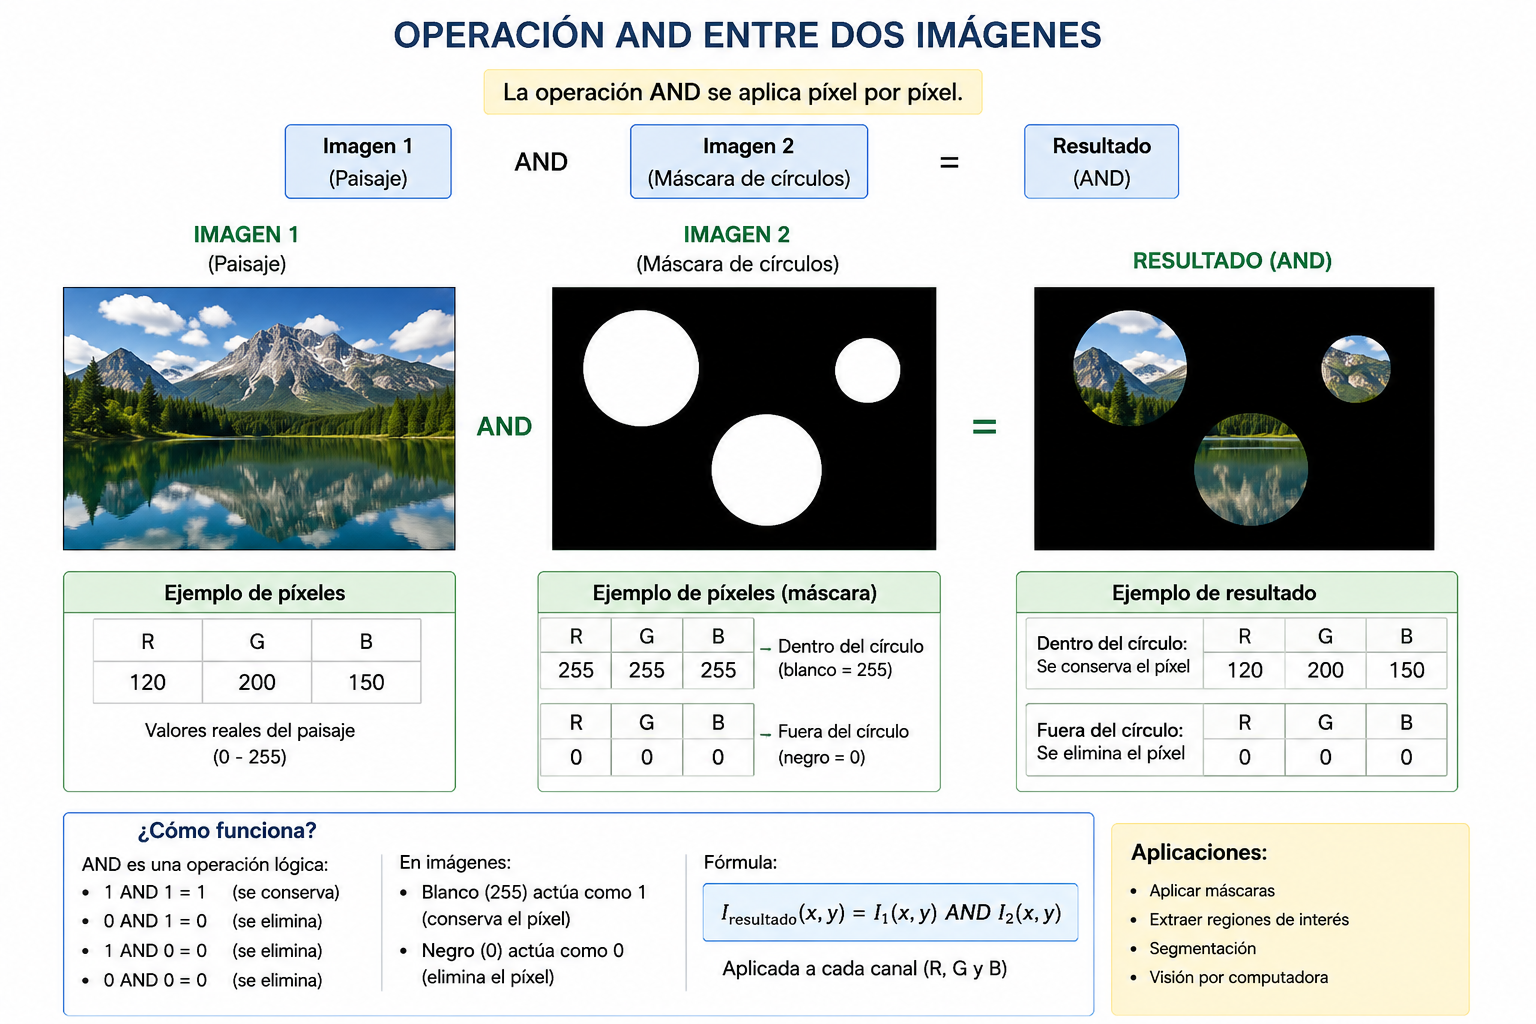

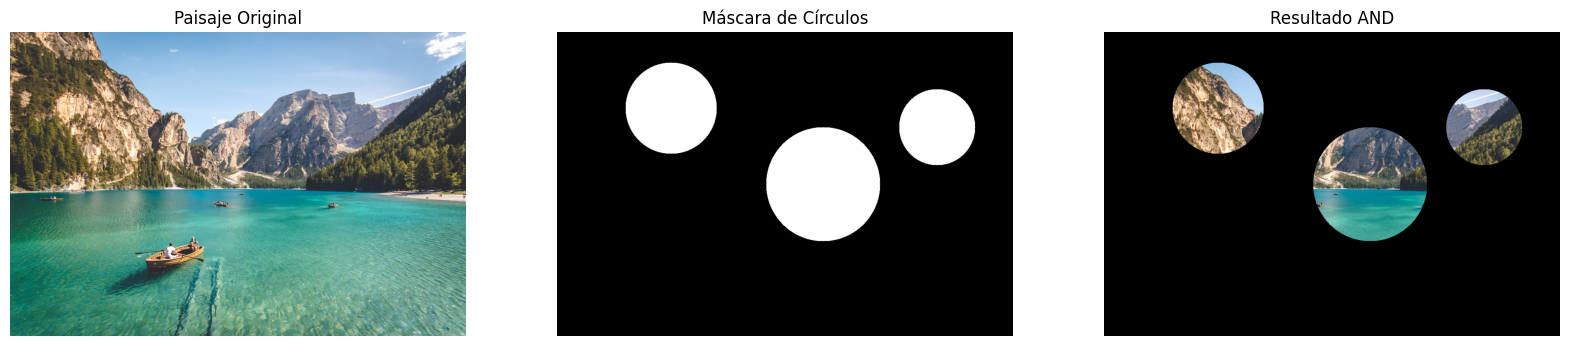

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# =========================
# CARGAR PAISAJE
# =========================

url = "https://images.unsplash.com/photo-1501785888041-af3ef285b470?w=1200"

req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)

# OpenCV carga en BGR
paisaje = cv2.imdecode(arr, cv2.IMREAD_COLOR)

# =========================
# CREAR IMAGEN DE CÍRCULOS
# =========================

# Crear imagen negra del mismo tamaño
circulos = np.zeros_like(paisaje)

# Dibujar círculos blancos
cv2.circle(circulos, (300,200), 120, (255,255,255), -1)
cv2.circle(circulos, (700,400), 150, (255,255,255), -1)
cv2.circle(circulos, (1000,250), 100, (255,255,255), -1)

# =========================
# OPERACIÓN AND
# =========================

resultado_and = cv2.bitwise_and(paisaje, circulos)

# =========================
# CONVERTIR A RGB
# =========================

paisaje_rgb = cv2.cvtColor(paisaje, cv2.COLOR_BGR2RGB)
circulos_rgb = cv2.cvtColor(circulos, cv2.COLOR_BGR2RGB)
and_rgb = cv2.cvtColor(resultado_and, cv2.COLOR_BGR2RGB)

# =========================
# MOSTRAR RESULTADOS
# =========================

plt.figure(figsize=(20,7))

# Paisaje original
plt.subplot(1,3,1)
plt.imshow(paisaje_rgb)
plt.title("Paisaje Original")
plt.axis("off")

# Máscara de círculos
plt.subplot(1,3,2)
plt.imshow(circulos_rgb)
plt.title("Máscara de Círculos")
plt.axis("off")

# Resultado AND
plt.subplot(1,3,3)
plt.imshow(and_rgb)
plt.title("Resultado AND")
plt.axis("off")

plt.show()